# **Задача кластеризации**

**Задача кластеризации** - это задача разделения набора данных на группы, называемые кластерами, так чтобы точки в одном кластере были очень похожи, а точки в разных кластерах были разными.

## **1. Метод k средних**

Метод кластеризации k-средних - один из простейших и наиболее часто используемых алгоритмов кластеризации. Он пытается найти центры кластеров, для чего последовательно выполняются два действия: присвоение каждой точки данных ближайшему центру кластера, а затем установка каждого центра кластера как среднее значение точек данных, которые ему назначены. Алгоритм завершен, когда назначение экземпляров кластерам больше не меняется.

## **Шаг 1. Загрузка данных**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

# from sklearn.model_selection import train_test_split

In [16]:
df = pd.read_excel("online_retail_II.xlsx")

In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom


## **Шаг 2. Первичный анализ (EDA — базовый)**

In [12]:
df.head(3)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   Price        525461 non-null  float64
 5   Customer ID  417534 non-null  float64
 6   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 28.1+ MB


In [14]:
df.tail()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,3.75,17530.0,United Kingdom
525460,538171,21931,JUMBO STORAGE BAG SUKI,2,1.95,17530.0,United Kingdom


In [17]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [20]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'Price',
       'Customer ID', 'Country'],
      dtype='object')

## **Шаг 3. Чистим НЕнужные колонки**

In [19]:
df = df.drop("InvoiceDate", axis=1)

In [33]:
df = df.drop("Description", axis=1)

## **Шаг 4 Работа с пропусками в данных**

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   Price        525461 non-null  float64
 5   Customer ID  417534 non-null  float64
 6   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 28.1+ MB


In [32]:
df['Price'].isna().sum()

np.int64(0)

In [36]:
df = df.dropna(subset=['Customer ID'])

In [38]:
df.isnull().sum()

Invoice        0
StockCode      0
Quantity       0
Price          0
Customer ID    0
Country        0
dtype: int64

## **Шаг 5 Разведочный анализ данных - EDA**

In [40]:
df

,Invoice,StockCode,Quantity,Price,Customer ID,Country
0,489434,85048,12,6.95,13085.0,United Kingdom
1,489434,79323P,12,6.75,13085.0,United Kingdom
2,489434,79323W,12,6.75,13085.0,United Kingdom
3,489434,22041,48,2.10,13085.0,United Kingdom
4,489434,21232,24,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...
525456,538171,22271,2,2.95,17530.0,United Kingdom
525457,538171,22750,1,3.75,17530.0,United Kingdom
525458,538171,22751,1,3.75,17530.0,United Kingdom
525459,538171,20970,2,3.75,17530.0,United Kingdom


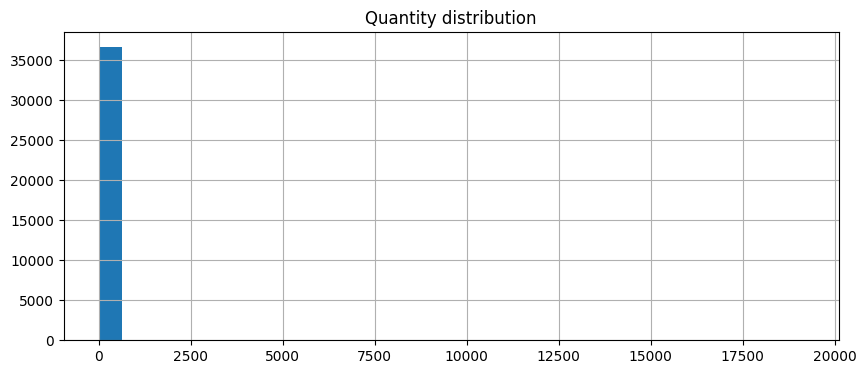

In [67]:
plt.figure(figsize=(10,4))
plt.hist(df['Quantity'].dropna(), bins=30)
plt.title('Quantity distribution')
plt.grid()
plt.show()

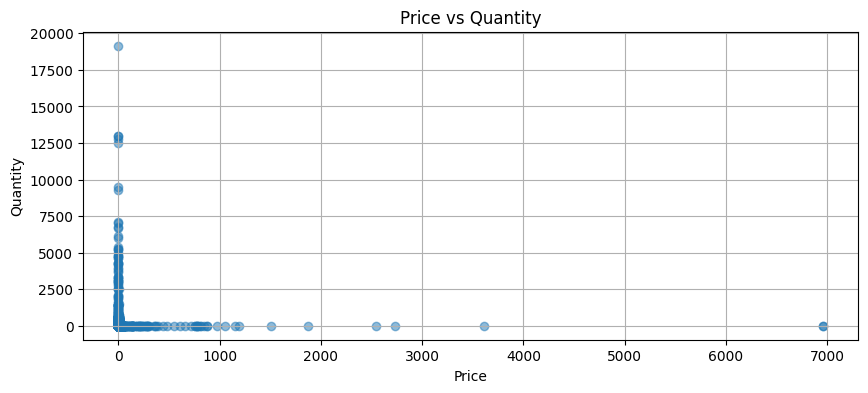

In [68]:
plt.figure(figsize=(10,4))
plt.scatter(df['Price'], df['Quantity'], alpha=0.5)
plt.title('Price vs Quantity')
plt.xlabel('Price')
plt.ylabel('Quantity')
plt.grid()
plt.show()

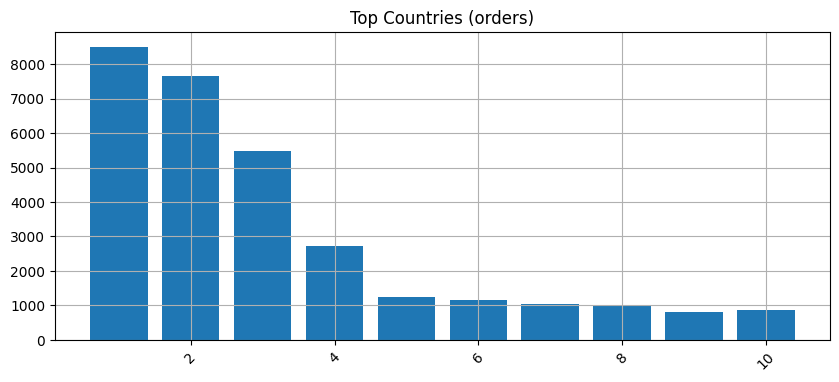

In [70]:
top_countries = df['Country'].value_counts().head(10)
plt.figure(figsize=(10,4))
plt.bar(top_countries.index, top_countries.values)
plt.xticks(rotation=45)
plt.title('Top Countries (orders)')
plt.grid()
plt.show()

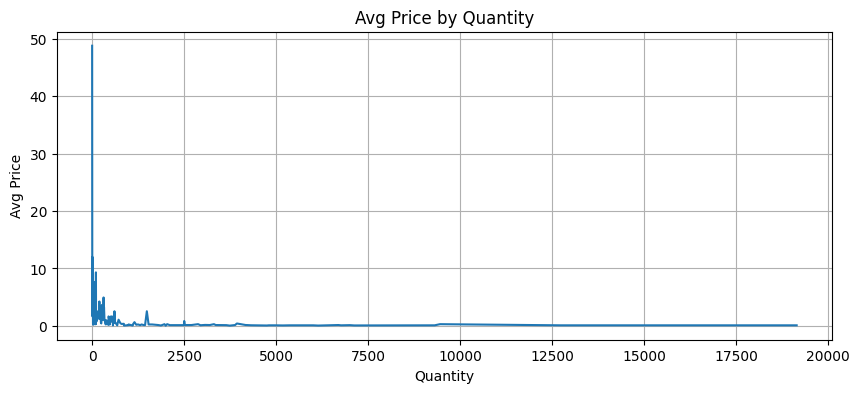

In [71]:
grouped = df.groupby('Quantity')['Price'].mean().sort_index()

plt.figure(figsize=(10,4))
plt.plot(grouped.index, grouped.values)
plt.title('Avg Price by Quantity')
plt.xlabel('Quantity')
plt.ylabel('Avg Price')
plt.grid()
plt.show()

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417534 entries, 0 to 525460
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      417534 non-null  object 
 1   StockCode    417534 non-null  object 
 2   Quantity     417534 non-null  int64  
 3   Price        417534 non-null  float64
 4   Customer ID  417534 non-null  float64
 5   Country      417534 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 22.3+ MB


## **Шаг 6 Кодирование данных (Label or OneHot Encoding)**

In [44]:
df['Country'].value_counts(dropna=False).index

Index(['United Kingdom', 'EIRE', 'Germany', 'France', 'Netherlands', 'Spain',
       'Switzerland', 'Belgium', 'Portugal', 'Channel Islands', 'Sweden',
       'Italy', 'Australia', 'Cyprus', 'Austria', 'Greece', 'Denmark',
       'Norway', 'Finland', 'United Arab Emirates', 'Unspecified', 'USA',
       'Japan', 'Poland', 'Malta', 'Lithuania', 'Singapore', 'Canada',
       'Thailand', 'Israel', 'Iceland', 'RSA', 'Korea', 'Brazil',
       'West Indies', 'Bahrain', 'Nigeria'],
      dtype='object', name='Country')

In [45]:
df['Country'] = df['Country'].replace({
    'United Kingdom': 0,
    'EIRE': 1,
    'Germany': 2,
    'France': 3,
    'Netherlands': 4,
    'Spain': 5,
    'Switzerland': 6,
    'Belgium': 7,
    'Portugal': 8,
    'Channel Islands': 9,
    'Sweden': 10,
    'Italy': 11,
    'Australia': 12,
    'Cyprus': 13,
    'Austria': 14,
    'Greece': 15,
    'Denmark': 16,
    'Norway': 17,
    'Finland': 18,
    'United Arab Emirates': 19,
    'Unspecified': 20,
    'USA': 21,
    'Japan': 22,
    'Poland': 23,
    'Malta': 24,
    'Lithuania': 25,
    'Singapore': 26,
    'Canada': 27,
    'Thailand': 28,
    'Israel': 29,
    'Iceland': 30,
    'RSA': 31,
    'Korea': 32,
    'Brazil': 33,
    'West Indies': 34,
    'Bahrain': 35,
    'Nigeria': 36
})

C:\Users\User\AppData\Local\Temp\ipykernel_4228\2892977278.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Country'] = df['Country'].replace({


In [46]:
df['Country'].value_counts()

Country
0     379423
1       8710
2       8129
3       5710
4       2769
5       1278
6       1187
7       1054
8       1024
9        906
10       883
11       731
12       654
13       554
14       537
15       517
16       428
17       369
18       354
19       318
20       280
21       244
22       224
23       194
24       172
25       154
26       117
27        77
28        76
29        74
30        71
31        65
32        63
33        62
34        54
35        42
36        30
Name: count, dtype: int64

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417534 entries, 0 to 525460
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      417534 non-null  object 
 1   StockCode    417534 non-null  object 
 2   Quantity     417534 non-null  int64  
 3   Price        417534 non-null  float64
 4   Customer ID  417534 non-null  float64
 5   Country      417534 non-null  int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 22.3+ MB


In [50]:
df['Quantity'].value_counts()

Quantity
1       80368
2       59917
12      59809
6       42561
4       30026
        ...  
1584        1
69          1
378         1
1488        1
1394        1
Name: count, Length: 343, dtype: int64

In [52]:
df['Invoice'].value_counts()

Invoice
500356    270
511522    255
531382    251
507235    250
511051    248
         ... 
519903      1
489444      1
489447      1
538101      1
538050      1
Name: count, Length: 19215, dtype: int64

In [55]:
df.columns

Index(['Invoice', 'StockCode', 'Quantity', 'Price', 'Customer ID', 'Country'], dtype='object')

In [72]:
df = df[df['Invoice'] > 0]

#удаляем с минусами тоесть те которые с возвратами !!

In [57]:
df = df[df['Quantity'] > 0]

In [58]:
df = df[df['Price'] > 0]

In [ ]:
df = df[df['Price'] > 0]

In [60]:
df = df[df['Country'] > 0]

In [61]:
df['Invoice'].value_counts()

Invoice
532993    200
525764    190
533088    164
507210    147
514387    135
         ... 
491169      1
537090      1
489831      1
489447      1
489444      1
Name: count, Length: 1601, dtype: int64

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36735 entries, 71 to 524545
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Invoice      36735 non-null  int16  
 1   StockCode    36735 non-null  int16  
 2   Quantity     36735 non-null  int64  
 3   Price        36735 non-null  float64
 4   Customer ID  36735 non-null  float64
 5   Country      36735 non-null  int64  
dtypes: float64(2), int16(2), int64(2)
memory usage: 1.5 MB


In [63]:
df['Invoice'] = df['Invoice'].astype('category').cat.codes
df['StockCode'] = df['StockCode'].astype('category').cat.codes

### **7. Корреляционный анализ**

In [94]:
df.columns

Index(['Invoice', 'StockCode', 'Quantity', 'Price', 'Customer ID', 'Country',
       'Clusters'],
      dtype='object')

In [95]:
df.corr()

,Invoice,StockCode,Quantity,Price,Customer ID,Country,Clusters
Invoice,1.000000,0.072786,-0.036082,-0.010708,-0.021856,0.061692,-0.030613
StockCode,0.072786,1.000000,-0.018545,0.069533,0.032373,0.010165,-0.011144
Quantity,-0.036082,-0.018545,1.000000,-0.006836,0.042643,0.032408,0.912820
Price,-0.010708,0.069533,-0.006836,1.000000,0.018964,0.007034,-0.002543
Customer ID,-0.021856,0.032373,0.042643,0.018964,1.000000,-0.049589,0.018401
Country,0.061692,0.010165,0.032408,0.007034,-0.049589,1.000000,0.038549
Clusters,-0.030613,-0.011144,0.912820,-0.002543,0.018401,0.038549,1.000000


## **8. Моделирование**

In [66]:
df.columns

Index(['Invoice', 'StockCode', 'Quantity', 'Price', 'Customer ID', 'Country'], dtype='object')

In [14]:
# df.iloc[:, 1:]

In [82]:
X = df[['Quantity', 'Price']]

In [83]:
X.shape

(36716, 2)

## **Масштабирование**

In [19]:
# # импортируем необходимый класс из модуля preprocessing библиотеки sklearn
# from sklearn.preprocessing import StandardScaler

# # создадим объект этого класса
# scaler = StandardScaler()

# # приведем данные к единому масштабу
# X = scaler.fit_transform(X)

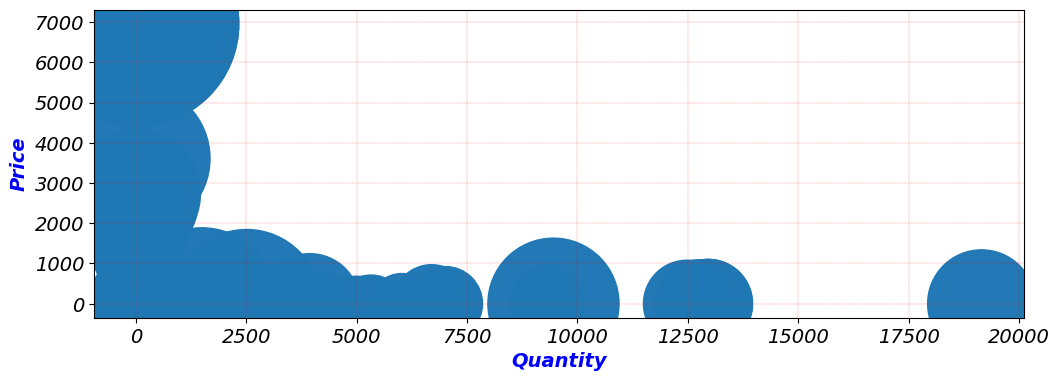

In [84]:
ar = np.pi * 2 * (df['Quantity'] * df['Price']).values * 0.5

plt.figure(figsize=(12, 4))
plt.scatter(
    x=df['Quantity'],
    y=df['Price'],
    alpha=0.99,
    s=ar
)

plt.xticks(color='black', fontsize=14, style="oblique", rotation=0)
plt.yticks(color='black', fontsize=14, style="oblique", rotation=0)

plt.xlabel("Quantity", color='blue', fontweight='bold', fontsize=14, style="oblique")
plt.ylabel("Price", fontweight='bold', color='blue', fontsize=14, style="oblique")

plt.grid(color='red', linestyle=':', linewidth=0.3)
plt.show()

## **Алгоритм K-means**

In [85]:
from sklearn.cluster import KMeans

In [86]:
k_means = KMeans(init = "k-means++", n_clusters = 3, random_state=21)
k_means.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,21
,copy_x,True
,algorithm,'lloyd'


In [87]:
labels = k_means.labels_
print(labels)

[0 0 0 ... 0 0 0]


In [88]:
df['Clusters'] = labels
df.head()

,Invoice,StockCode,Quantity,Price,Customer ID,Country,Clusters
126,1,2884,1,141.00,12636.0,21,0
173,2,2884,1,130.00,12362.0,7,0
187,3,1020,12,2.95,16321.0,12,0
188,3,2795,6,1.65,16321.0,12,0
189,3,886,4,4.25,16321.0,12,0


In [89]:
df.groupby('Clusters').mean(numeric_only=True)

,Invoice,StockCode,Quantity,Price,Customer ID,Country
Clusters,,,,,,
0,811.027763,1247.652067,22.564798,4.805986,13380.327179,5.596106
1,441.195122,1080.536585,4221.756098,0.169756,14030.048780,11.560976
2,298.857143,786.000000,12723.428571,0.128571,13902.000000,16.000000


In [91]:
df['Price'].value_counts()

Price
1.25      4058
0.85      3590
1.65      3244
2.95      2961
0.42      2073
          ... 
850.00       1
253.00       1
165.00       1
65.00        1
42.95        1
Name: count, Length: 210, dtype: int64

In [ ]:
# import plotly.express as px
# fig = px.scatter_3d(df, x='Edu', y='Age', z='Income', color='Clusters', opacity=0.9, size_max=5)
# fig.show()

# fig = px.scatter_3d(df, x='Years Employed', y='Age', z='Income', color='Clusters', opacity=0.9, size_max=5)
# fig.show()

In [92]:
wcss=[]

LEN = 11
for i in range(1, LEN):
    kmeans = KMeans(n_clusters= i, init='k-means++', random_state=21, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

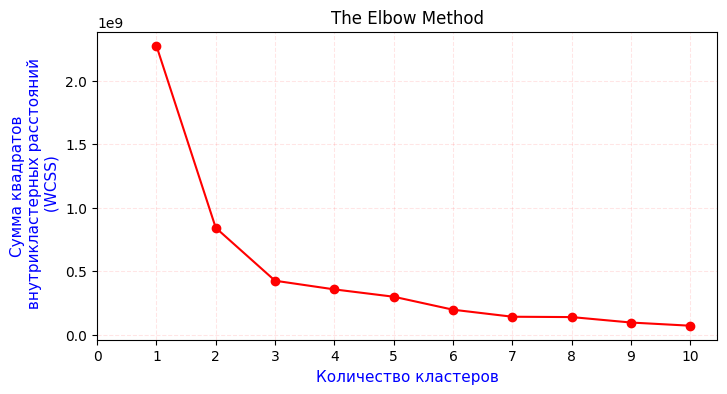

In [93]:
# Метод локтя

plt.figure(figsize=(8, 4))
plt.plot(range(1, LEN), wcss, 'ro', linestyle='-')
plt.title('The Elbow Method')
plt.xlabel('Количество кластеров', fontsize=11, color='b')
plt.ylabel('Сумма квадратов\n внутрикластерных расстояний\n (WCSS)', fontsize=11, color='b')
plt.xticks(np.arange(0, LEN, 1))
plt.grid(alpha=0.1, color='r', linestyle='--')
plt.show()